# Lec - 4.1 Observational Study with discrete covariate


## Setup Experiment Parameters and Simulate Ground truth

In [16]:
true_treatment_effect = 1

sample_size = 1000
control_effect = 10

print(f"True Treatment Effect: {true_treatment_effect}")
print(f"Sample Size: {sample_size}")

True Treatment Effect: 1
Sample Size: 1000


In [17]:

def simulate_ground_truth(sample_size):
  feature_p = 0.5
  feature = np.random.binomial(n=1, p=feature_p, size=sample_size)
  feature_trans= feature * 10 - 4
  potential_outcome_control = np.random.normal(loc=control_effect, scale=2, size=sample_size)
  potential_outcome_treatment = potential_outcome_control + true_treatment_effect *feature_trans

  return feature, potential_outcome_control, potential_outcome_treatment

## Observational Data

In [13]:
propensity = [0.3,0.7]
def obs(propensity,sample_size):

  feature, potential_outcome_control, potential_outcome_treatment = simulate_ground_truth(sample_size)



  treatment_assignment = np.zeros(sample_size, dtype=int)
  feature_0_indices = np.where(feature == 0)[0]
  feature_1_indices = np.where(feature == 1)[0]
  e0 = propensity[0]
  e1 = propensity[1]



  treatment_assignment[feature_0_indices] = np.random.binomial(n=1, p=e0, size= len(feature_0_indices))


  treatment_assignment[feature_1_indices] = np.random.binomial(n=1, p=e1, size= len(feature_1_indices))

  # Calculate observed outcome
  observed_outcome = np.where(treatment_assignment == 1, potential_outcome_treatment, potential_outcome_control)

  return feature, treatment_assignment, observed_outcome

## Estimators



In [5]:
import numpy as np


def estimate_dim(sample_size):



    _,treatment_assignment, observed_outcome = obs(propensity, sample_size)

    # Separate observed outcomes into treatment and control groups
    observed_outcome_treatment_group = observed_outcome[treatment_assignment == 1]
    observed_outcome_control_group = observed_outcome[treatment_assignment == 0]
    n1 = len(observed_outcome_treatment_group)
    n0 = len(observed_outcome_control_group)
    var_estimate = np.var(observed_outcome_treatment_group) / n1 + np.var(observed_outcome_control_group) / n0


    dim_estimate = np.mean(observed_outcome_treatment_group) - np.mean(observed_outcome_control_group)


    return dim_estimate, var_estimate




In [7]:
def estimate_strata(sample_size):

    feature, treatment_assignment, observed_outcome =obs(propensity, sample_size)

    # Filter data for feature == 0
    feature_0_indices = (feature == 0)
    w0 = sum(feature_0_indices) / sample_size
    ta_feature_0 = treatment_assignment[feature_0_indices]
    oo_feature_0 = observed_outcome[feature_0_indices]

    # Calculate DiM for feature == 0
    oo_feature_0_treatment = oo_feature_0[ta_feature_0 == 1]
    oo_feature_0_control = oo_feature_0[ta_feature_0 == 0]

    dim_feature_0 = np.mean(oo_feature_0_treatment) - np.mean(oo_feature_0_control)
    var_estimate_0 = np.var(oo_feature_0_treatment)/len(oo_feature_0_treatment) + np.var(oo_feature_0_control)/len(oo_feature_0_control)

    # Filter data for feature == 1
    feature_1_indices = (feature == 1)
    w1 = sum(feature_1_indices) / sample_size
    ta_feature_1 = treatment_assignment[feature_1_indices]
    oo_feature_1 = observed_outcome[feature_1_indices]

    # Calculate DiM for feature == 1
    oo_feature_1_treatment = oo_feature_1[ta_feature_1 == 1]
    oo_feature_1_control = oo_feature_1[ta_feature_1 == 0]

    dim_feature_1 = np.mean(oo_feature_1_treatment) - np.mean(oo_feature_1_control)
    var_estimate_1= np.var(oo_feature_1_treatment)/len(oo_feature_1_treatment) + np.var(oo_feature_1_control)/len(oo_feature_1_control)

    est = w0 * dim_feature_0 + w1 * dim_feature_1
    var_tau_est = (w0 * (dim_feature_0 - est) ** 2 + w1 * (dim_feature_1 - est) ** 2) / sample_size
    var_est = var_estimate_0 * (w0 ** 2)+ var_estimate_1 * (w1 ** 2) + var_tau_est

    return est, var_est




In [8]:
def inference(estimate, var):
  return int(np.abs(estimate - true_treatment_effect) / np.sqrt(var) >= 1.96)

## Run Simulations



In [9]:
num_simulations = 1000

dim_estimates = []
dim_var_estimates = []
dim_err = 0
stra_estimates = []
stra_var_estimates = []
post_err = 0
strat_err = 0

for i in range(num_simulations):


    # Simulate and estimate using DiM
    dim_estimate, var_est = estimate_dim(sample_size)
    dim_estimates.append(dim_estimate)
    dim_var_estimates.append(var_est)


    # Simulate and estimate using IPW
    stra_est, var_est = estimate_strata(sample_size)
    stra_estimates.append(stra_est)
    stra_var_estimates.append(var_est)
    strat_err += inference(stra_est, var_est)




print(f"mean of DiM Estimate: {np.mean(dim_estimate):.4f}" )

print(f"Variance of Stratified Estimate: {np.var(stra_estimates):.4f}, expectation of Stratified variance: {np.mean(stra_var_estimates):.4f}" )

print(f"Stratified Error: {strat_err /num_simulations:.4f}")

mean of DiM Estimate: 2.9096
Variance of Stratified Estimate: 0.0423, expectation of Stratified variance: 0.0441
Stratified Error: 0.0530


## Analyze and Plot Results




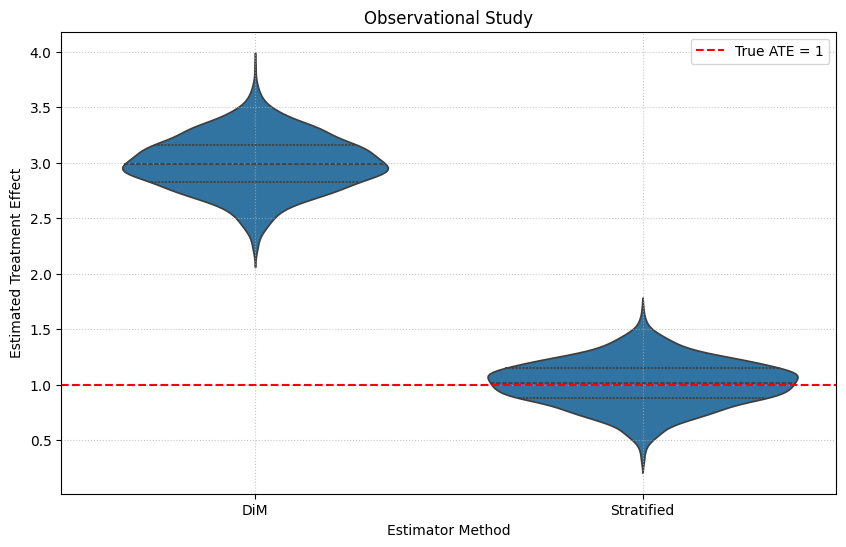

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Combine the estimates into a DataFrame for easier plotting
data = {
    'Estimator': ['DiM'] * len(dim_estimates) + ['Stratified'] * len(stra_estimates) ,
    'Estimate': dim_estimates + stra_estimates
}
df = pd.DataFrame(data)

# Create the violin plot
plt.figure(figsize=(10, 6))
sns.violinplot(x='Estimator', y='Estimate', data=df, inner='quartile')

# Add a horizontal dotted line for the true treatment effect
plt.axhline(y=true_treatment_effect, color='r', linestyle='--', label=f'True ATE = {true_treatment_effect}')

# Add labels and title
plt.title('Observational Study')
plt.xlabel('Estimator Method')
plt.ylabel('Estimated Treatment Effect')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)
plt.show()